In [1]:
import matplotlib
matplotlib.use("Agg")
import plotly.io as pio
pio.renderers.default = "png"

# Getting started

This page walks through a complete analysis end to end, then points you at the
task guides for more depth.

## Install

```bash
pip install moderndive
```

`moderndive` returns [polars](https://pola.rs) DataFrames, but every function also
accepts pandas DataFrames as input.

## Load a dataset

All datasets ship with the package and load with `load_<name>()`:

In [2]:
import moderndive as md

promotions = md.load_promotions()
promotions.head()

id,decision,gender
i64,str,str
1,"""promoted""","""male"""
2,"""promoted""","""male"""
3,"""promoted""","""male"""
4,"""promoted""","""male"""
5,"""promoted""","""male"""


List everything that's available with `md.available_datasets()` (58 datasets), and
see {doc}`datasets` for a thematic tour.

## A first summary

`tidy_summary` gives a per-variable five-number summary (numeric) or counts
(categorical):

In [3]:
from moderndive import tidy_summary

tidy_summary(md.load_almonds_sample_100(), columns=["weight"])

column,n,group,type,min,Q1,mean,median,Q3,max,sd
str,i64,str,str,f64,f64,f64,f64,f64,f64,f64
"""weight""",100,null,"""numeric""",2.9,3.4,3.682,3.7,3.9,4.5,0.362


## The inference pipeline

The core grammar mirrors R `infer`. You build a pipeline and read it like a
sentence:

In [4]:
from moderndive import specify, observe, get_p_value

# 1. The observed statistic
obs = observe(
    promotions, formula="decision ~ gender", success="promoted",
    stat="diff in props", order=("male", "female"),
)

# 2. A null distribution: specify → hypothesize → generate → calculate
null = (
    specify(promotions, formula="decision ~ gender", success="promoted")
    .hypothesize(null="independence")
    .generate(reps=1000, type="permute", seed=42)
    .calculate(stat="diff in props", order=("male", "female"))
)

# 3. Summarize
get_p_value(null, obs_stat=obs, direction="right")   # ≈ 0.025

p_value
f64
0.025


Each verb has a focused guide: {doc}`guides/sampling`,
{doc}`guides/confidence-intervals`, and {doc}`guides/hypothesis-testing`.

## Visualizing — choose your engine

Plots default to **plotly** (interactive). Pass `engine="plotnine"` for
grammar-of-graphics output. The composition syntax is identical:

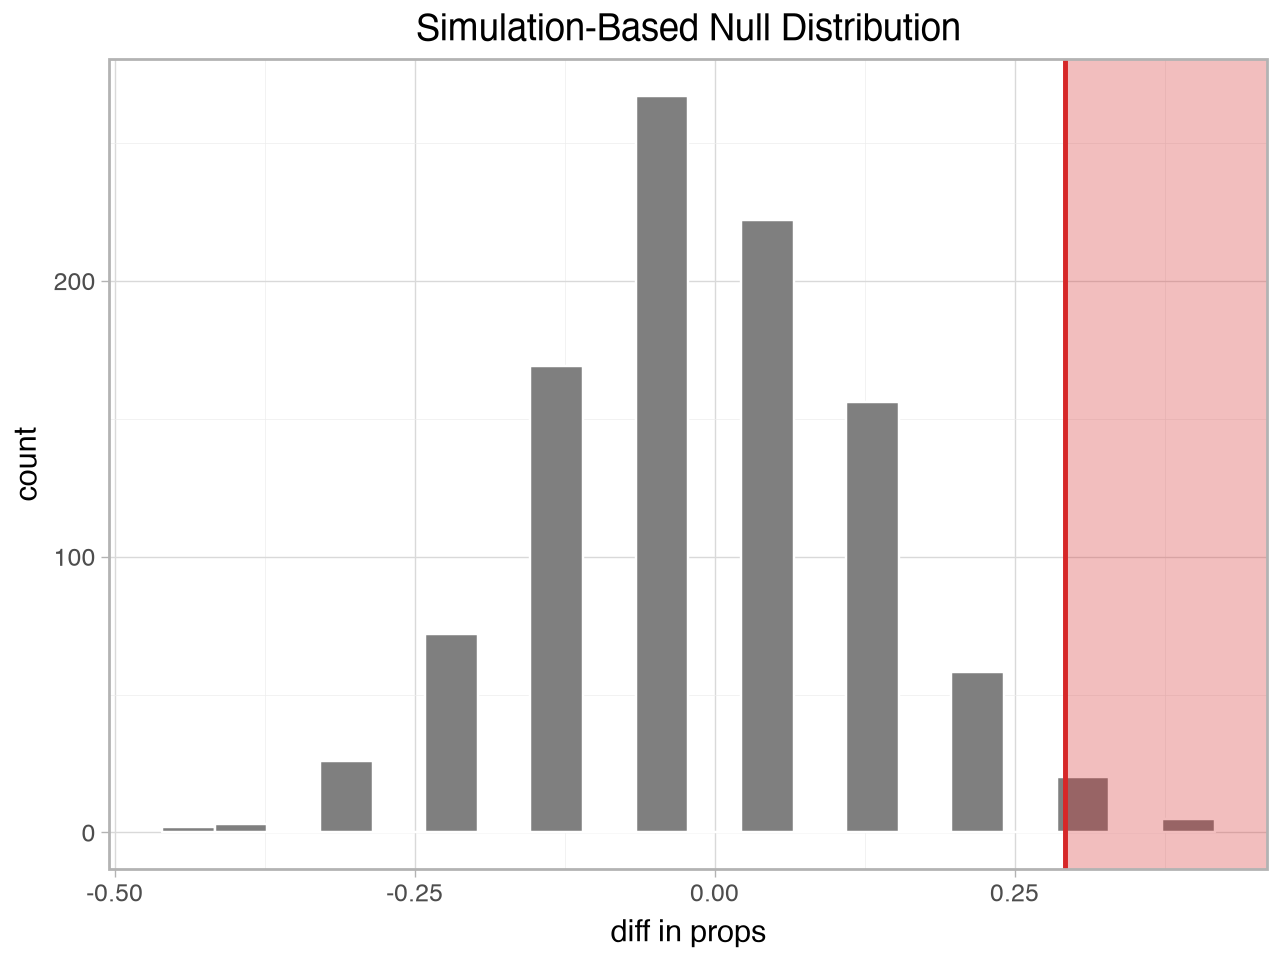

In [5]:
from moderndive import visualize, shade_p_value

# Interactive plotly figure
visualize(null) + shade_p_value(obs_stat=obs, direction="right")

# Same plot, plotnine
visualize(null, engine="plotnine") + shade_p_value(obs_stat=obs, direction="right")

See {doc}`guides/plotting` for shading, confidence-interval overlays, theoretical
overlays, and the regression-model plots.

## Regression

In [6]:
import statsmodels.formula.api as smf
from moderndive import get_regression_table

houses = md.load_saratoga_houses()
model = smf.ols("price ~ living_area + bedrooms", data=houses.to_pandas()).fit()
get_regression_table(model)

term,estimate,std_error,statistic,p_value,lower_ci,upper_ci
str,f64,f64,f64,f64,f64,f64
"""intercept""",20986.094,6816.251,3.079,0.002,7611.128,34361.06
"""living_area""",93.842,3.109,30.183,0.0,87.741,99.943
"""bedrooms""",-7483.095,2783.531,-2.688,0.007,-12944.988,-2021.203


Full details in {doc}`guides/regression`.